## Используемые библиотеки

In [ ]:
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

from tensorflow.keras.datasets import mnist


import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


## Загрузка и подготовка данных

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 1, 32, 32), метки: (60000,)
Test : (10000, 1, 32, 32), метки: (10000,)
Диапазон: [0.00, 1.00]
Классы: [0 1 2 3 4 5 6 7 8 9]


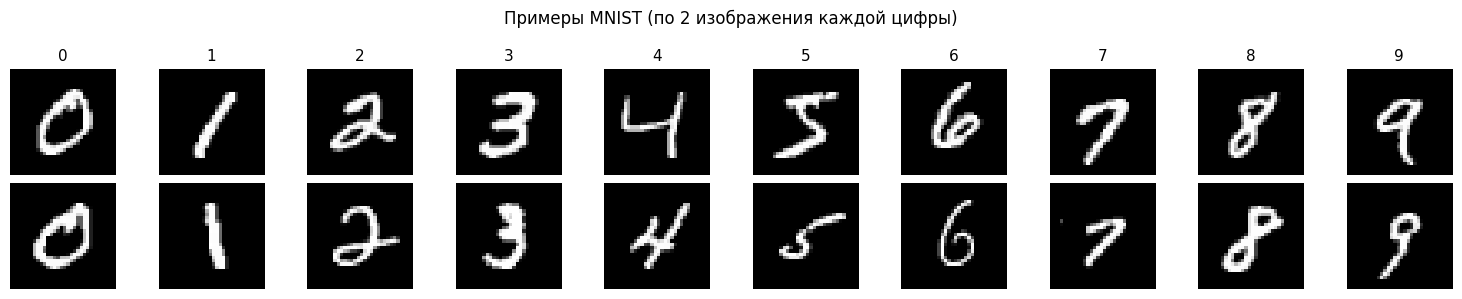


Обучающая подвыборка: (10000, 1, 32, 32)
Тестовая подвыборка:  (2000, 1, 32, 32)


In [ ]:
# ── Загрузка и подготовка MNIST ─────────────────────────────

(X_tr_raw, y_tr_raw), (X_te_raw, y_te_raw) = mnist.load_data()

# Нормализация в [0, 1]
X_tr_raw = X_tr_raw.astype(np.float64) / 255.0
X_te_raw = X_te_raw.astype(np.float64) / 255.0

# Добавляем ось канала: (N,28,28) → (N,1,28,28)
X_tr_raw = X_tr_raw[:, np.newaxis]
X_te_raw = X_te_raw[:, np.newaxis]

# Паддинг 28×28 → 32×32 (требование оригинального LeNet-5)
X_tr_mnist = np.pad(X_tr_raw, ((0,0),(0,0),(2,2),(2,2)))
X_te_mnist = np.pad(X_te_raw, ((0,0),(0,0),(2,2),(2,2)))

print(f'Train: {X_tr_mnist.shape}, метки: {y_tr_raw.shape}')
print(f'Test : {X_te_mnist.shape}, метки: {y_te_raw.shape}')
print(f'Диапазон: [{X_tr_mnist.min():.2f}, {X_tr_mnist.max():.2f}]')
print(f'Классы: {np.unique(y_tr_raw)}')

# Визуализация примеров
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    idx = np.where(y_tr_raw == digit)[0][0]
    axes[0, digit].imshow(X_tr_mnist[idx, 0], cmap='gray')
    axes[0, digit].set_title(str(digit), fontsize=11)
    axes[0, digit].axis('off')
    idx2 = np.where(y_tr_raw == digit)[0][1]
    axes[1, digit].imshow(X_tr_mnist[idx2, 0], cmap='gray')
    axes[1, digit].axis('off')
plt.suptitle('Примеры MNIST (по 2 изображения каждой цифры)', fontsize=12)
plt.tight_layout()
plt.show()

# Для разумного времени обучения используем подвыборку
N_TRAIN = 10000
N_TEST  = 2000

np.random.seed(42)

tr_idx = np.random.permutation(len(X_tr_mnist))[:N_TRAIN]
te_idx = np.random.permutation(len(X_te_mnist))[:N_TEST]

X_tr4 = X_tr_mnist[tr_idx]; y_tr4 = y_tr_raw[tr_idx]
X_te4 = X_te_mnist[te_idx]; y_te4 = y_te_raw[te_idx]

print(f'\nОбучающая подвыборка: {X_tr4.shape}')
print(f'Тестовая подвыборка:  {X_te4.shape}')

## Библиотечная реализация

Epoch  1 | Loss: 1.7307 | Train Acc: 0.4907 | Val Acc: 0.8415
Epoch  2 | Loss: 0.4477 | Train Acc: 0.8742 | Val Acc: 0.8980
Epoch  3 | Loss: 0.3067 | Train Acc: 0.9107 | Val Acc: 0.9305
Epoch  4 | Loss: 0.2447 | Train Acc: 0.9275 | Val Acc: 0.9410
Epoch  5 | Loss: 0.2000 | Train Acc: 0.9424 | Val Acc: 0.9495
Epoch  6 | Loss: 0.1680 | Train Acc: 0.9518 | Val Acc: 0.9580
Epoch  7 | Loss: 0.1414 | Train Acc: 0.9588 | Val Acc: 0.9595
Epoch  8 | Loss: 0.1209 | Train Acc: 0.9631 | Val Acc: 0.9670
Epoch  9 | Loss: 0.1072 | Train Acc: 0.9676 | Val Acc: 0.9690
Epoch 10 | Loss: 0.0923 | Train Acc: 0.9714 | Val Acc: 0.9685
Epoch 11 | Loss: 0.0793 | Train Acc: 0.9771 | Val Acc: 0.9730
Epoch 12 | Loss: 0.0708 | Train Acc: 0.9789 | Val Acc: 0.9740
Epoch 13 | Loss: 0.0620 | Train Acc: 0.9819 | Val Acc: 0.9735
Epoch 14 | Loss: 0.0562 | Train Acc: 0.9839 | Val Acc: 0.9780
Epoch 15 | Loss: 0.0486 | Train Acc: 0.9874 | Val Acc: 0.9795
Отчет по классам:
              precision    recall  f1-score   suppor

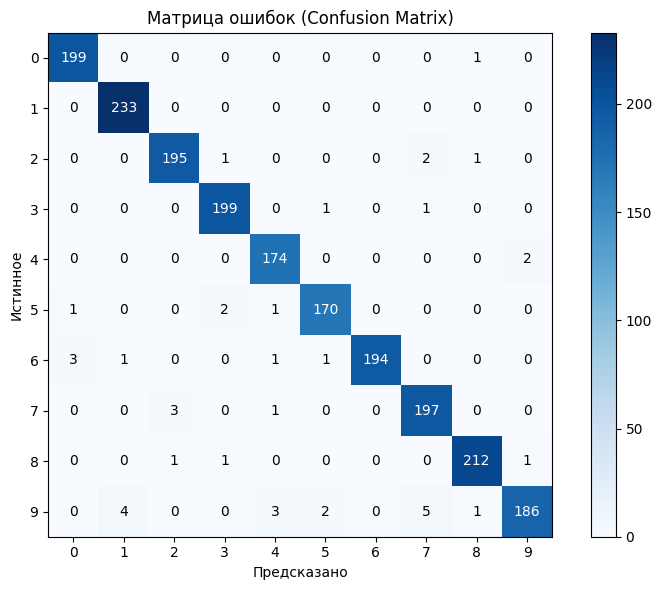

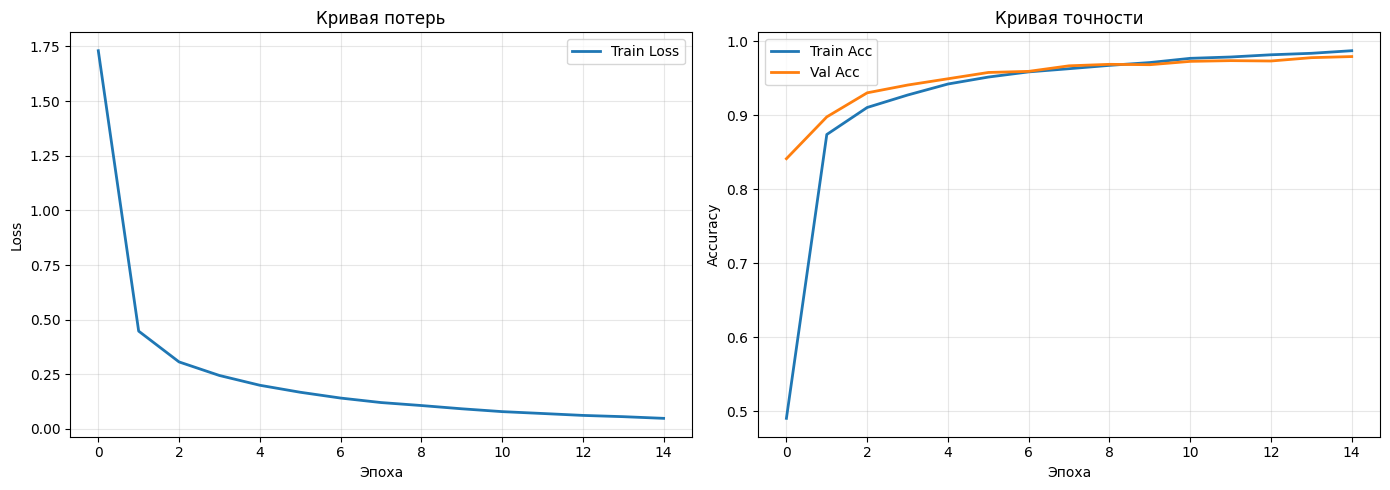

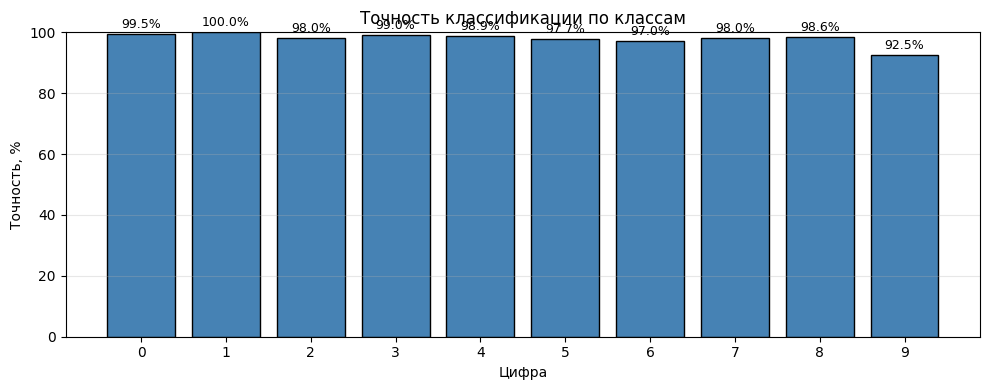


Итоговая точность на тесте: 97.95%
Средняя точность по классам: 97.92%


In [ ]:
# 1. Конвертация в тензоры
X_tr_t = torch.from_numpy(X_tr4).float()
y_tr_t = torch.from_numpy(y_tr4).long()
X_te_t = torch.from_numpy(X_te4).float()
y_te_t = torch.from_numpy(y_te4).long()

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
test_dl  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=256, shuffle=False)

# LeNet-5
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),
            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Инициализация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Обучение
epochs = 15

# Сбор метрик
train_losses, train_accs, val_accs = [], [], []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    train_losses.append(epoch_loss / len(train_dl))
    train_accs.append(correct_train / total_train)

    model.eval()
    correct_val = 0
    with torch.no_grad():
        for xb, yb in test_dl:
            logits = model(xb.to(device))
            preds = logits.argmax(dim=1)
            correct_val += (preds.cpu() == yb).sum().item()

    val_accs.append(correct_val / len(y_te_t))
    print(f'Epoch {epoch:2d} | Loss: {train_losses[-1]:.4f} | '
          f'Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}')

# Прогнозы на тесте
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb.to(device))
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

#  Метрики по классам
print("Отчет по классам:")
print(classification_report(all_labels, all_preds,
                           target_names=[str(i) for i in range(10)],
                           digits=4))

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.colorbar()
plt.xlabel('Предсказано')
plt.ylabel('Истинное')
plt.xticks(range(10))
plt.yticks(range(10))

thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

# Кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривая потерь')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Accuracy
axes[1].plot(train_accs, label='Train Acc', linewidth=2)
axes[1].plot(val_accs, label='Val Acc', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Кривая точности')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Точность по каждому классу
class_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(10, 4))
bars = plt.bar(range(10), class_acc, color='steelblue', edgecolor='black')
plt.xlabel('Цифра')
plt.ylabel('Точность, %')
plt.title('Точность классификации по классам')
plt.xticks(range(10))
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Подписи значений на столбцах
for bar, acc in zip(bars, class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nИтоговая точность на тесте: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"Средняя точность по классам: {class_acc.mean():.2f}%")